[Home](../../README.md)

### Data Preprocessing

This Jupyter Notebook demonstrates different processes you can apply to your data to better understand it before data wrangling. For this demonstration we will use relatively a complex real dataset that compares health measures with the speed of progress of type 2 adult onset diabetes.

#### Load the required dependencies

Load the two required dependencies:

- [Numpy](https://numpy.org/doc/stable/) is a library that enables numerical computing with Python
- [Pandas](https://pandas.pydata.org/) is library for data analysis and manipulation.
- [Matplotlib](https://matplotlib.org) a comprehensive library for creating static, animated, and interactive visualizations in Python. A customised stylesheet for the visualisations is also applied.

In [1]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('../../style_Matplotlib_charts.mplstyle')

####  Store the data as a local variable

The data frame is a Pandas object that structures your tabular data into an appropriate format. It loads the complete data in memory so it is now ready for preprocessing.

In [2]:
data_frame = pd.read_csv("spotify_songs.csv")

#### Data Snapshot

It is important to get a high-level look at your dataset to understand what you are working with. Printing the complete data might be impossible for large-scale datasets where the rows can be in thousands or even millions.

You can use the `head()` and `tail()` method call to inspect the first and last 5 rows of your dataset.

In [3]:
# Target = A measure of disease progression in one year
data_frame.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


####  Data Summary
 
The `info()` method call prints a summary of each column, giving you more information about the specific data types, total number of rows, null values and memory usage.

In [4]:
data_frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  str    
 1   track_name                32828 non-null  str    
 2   track_artist              32828 non-null  str    
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  str    
 5   track_album_name          32828 non-null  str    
 6   track_album_release_date  32833 non-null  str    
 7   playlist_name             32833 non-null  str    
 8   playlist_id               32833 non-null  str    
 9   playlist_genre            32833 non-null  str    
 10  playlist_subgenre         32833 non-null  str    
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudness         

#### Statistics For Numerical Columns
 
The `describe()` method call provides basic statistical knowledge like the mean and spread of the data.

In [5]:
data_frame.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000,32833.000000
mean,42.477081,0.654850,0.698619,5.374471,-6.719499,0.565711,0.107068,0.175334,0.084747,0.190176,0.510561,120.881132,225799.811622
std,24.984074,0.145085,0.180910,3.611657,2.988436,0.495671,0.101314,0.219633,0.224230,0.154317,0.233146,26.903624,59834.006182
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171000,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.960000,187819.000000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918000,253585.000000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


#### The data columns are:

| Column | Data | Datatype | Range | Units | 
| ------ | ----- | ----- | ----- | ----- | 
| track_popularity | Measure of popularity (likely target) | float | 0 to 1 | ? |
| track_album_release_date | Release date of album (other target idea) | datetime | Before February 2020 | N/A |
| playlist_genre | Genre of playlist | string | N/A | N/A |
| playlist_subgenre | Subgenre of playlist | string | N/A | N/A |
| danceability | Danceability of song^ | float | 0 to 1 | Abitrary |
| energy | Energy of song^ | float | 0 to 1 | Abitrary |
| key | Key of song^ | int | 0 to 11 | int notation/key |
| loudness | Overall loudness of song | float | -60 to 0* | Db |
| mode | modality of song (major = 1, minor = 0)^ | bool | 0 or 1 | N/A |
| speechiness | basically concentration of words^ () | float | 0 to 1 | Abitrary |
| acousticness | measure of confidence that the song is acoustic^ | float | 0 to 1 | Abitrary |
| instrumentalness | measure of instrumentalness^ (why have this and speechiness) | float | 0 to 1 | Abitrary |
| liveness | probability of song being live^ | float | 0 to 1 | Abitrary |
| valence | measure of valence^ | float | 0 to 1 | Abitrary |
| tempo | estimated tempo^ | float | 30 to 250** | beats per minute |
| duration_ms | duration of song | float | 29500 to 517800** | ms |


*typical range
**calulated range (aprox.)

^measured by ml so could be incorrect

note: ml feeding into ml is probably an issue and i need to research and address it to show my understanding.

#### Graphically present the data

At this early stage you are just wanting to evaluate the data, the below simple plots lets you look the data in different ways to inform your model design and data wrangling approaches.

In [6]:
data_frame["track_album_release_date"] = pd.to_datetime(
    data_frame["track_album_release_date"], format="mixed"
).dt.year

data_frame["track_album_release_date"] = (
    data_frame["track_album_release_date"]
    .fillna(data_frame["track_album_release_date"].mean())
    .astype(int)
)

print(data_frame["track_album_release_date"].unique())
print(data_frame["track_album_release_date"].info())

[2019 2018 2017 2016 2014 2012 2015 2013 2011 2010 2008 2020 2007 1998
 1996 1999 2009 1993 1995 1991 2000 1994 1992 1997 2001 2006 2002 2003
 2005 1990 2004 1988 1984 1982 1973 1979 1977 1981 1974 1970 1976 1987
 1978 1969 1986 1980 1983 1985 1989 1975 1968 1971 1972 1967 1966 1965
 1964 1963 1962 1957 1958 1961 1960]
<class 'pandas.Series'>
RangeIndex: 32833 entries, 0 to 32832
Series name: track_album_release_date
Non-Null Count  Dtype
--------------  -----
32833 non-null  int64
dtypes: int64(1)
memory usage: 256.6 KB
None


<Axes: >

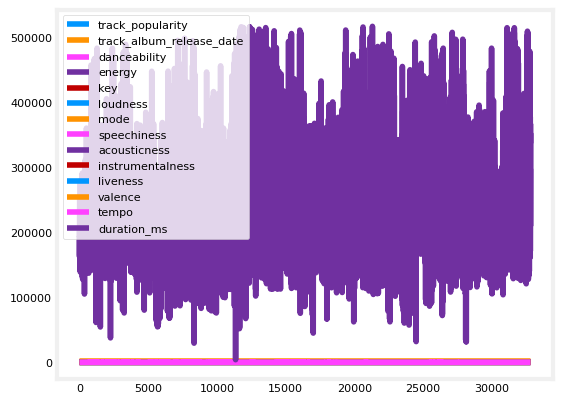

In [7]:
target = "track_album_release_date"
# plot a line graph
data_frame.plot()

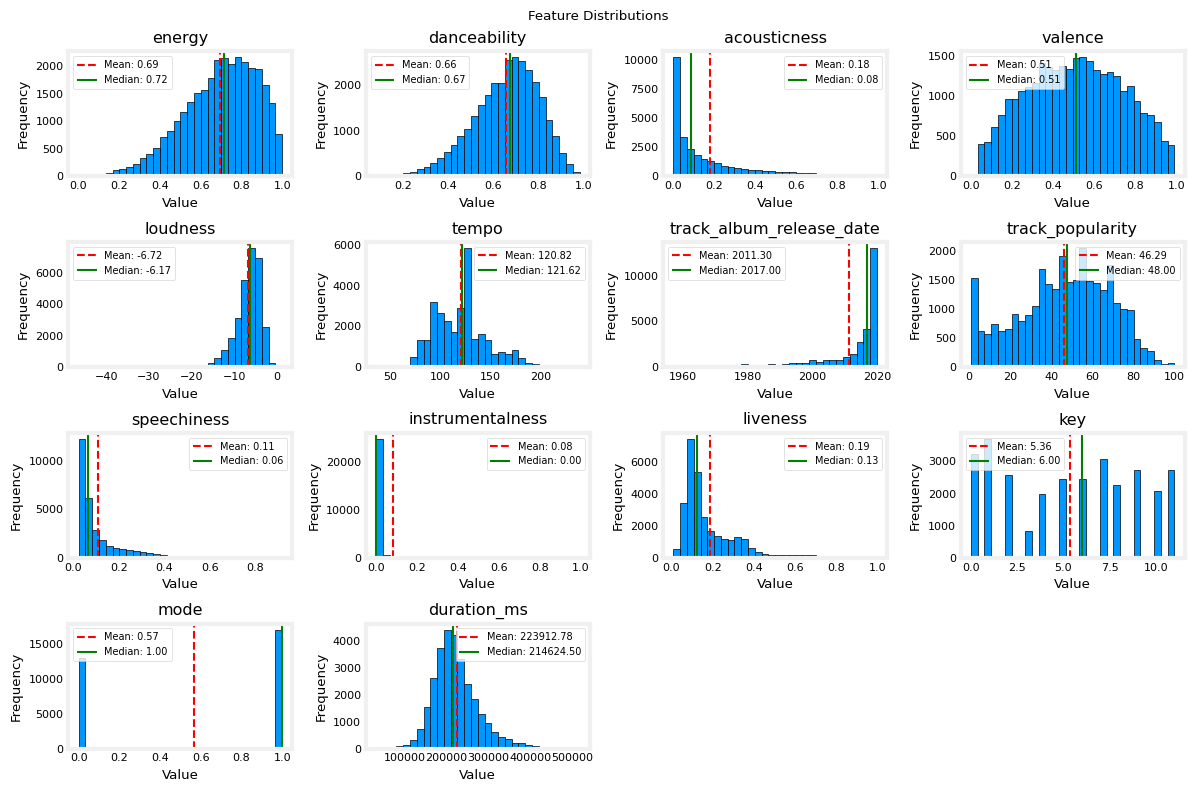

In [8]:
data_frame = data_frame[data_frame["track_popularity"] != 0]
features = [
    "energy",
    "danceability",
    "acousticness",
    "valence",
    "loudness",
    "tempo",
    "track_album_release_date",
    "track_popularity",
    "speechiness",
    "instrumentalness",
    "liveness",
    "key",
    "mode",
    "duration_ms"
]

fig, axes = plt.subplots(4, 4, figsize=(12, 8))
plt.suptitle("Feature Distributions")

for ax, feature in zip(axes.flatten(), features):
    mean = data_frame[feature].mean()
    median = data_frame[feature].median()

    ax.hist(data_frame[feature], bins=30, edgecolor="black")
    ax.axvline(
        mean, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean:.2f}"
    )
    ax.axvline(
        median,
        color="green",
        linestyle="-",
        linewidth=1.5,
        label=f"Median: {median:.2f}",
    )
    ax.set_title(feature)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=7)

for ax in axes.flatten()[len(features) :]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

abnormal 0 amount in popularity

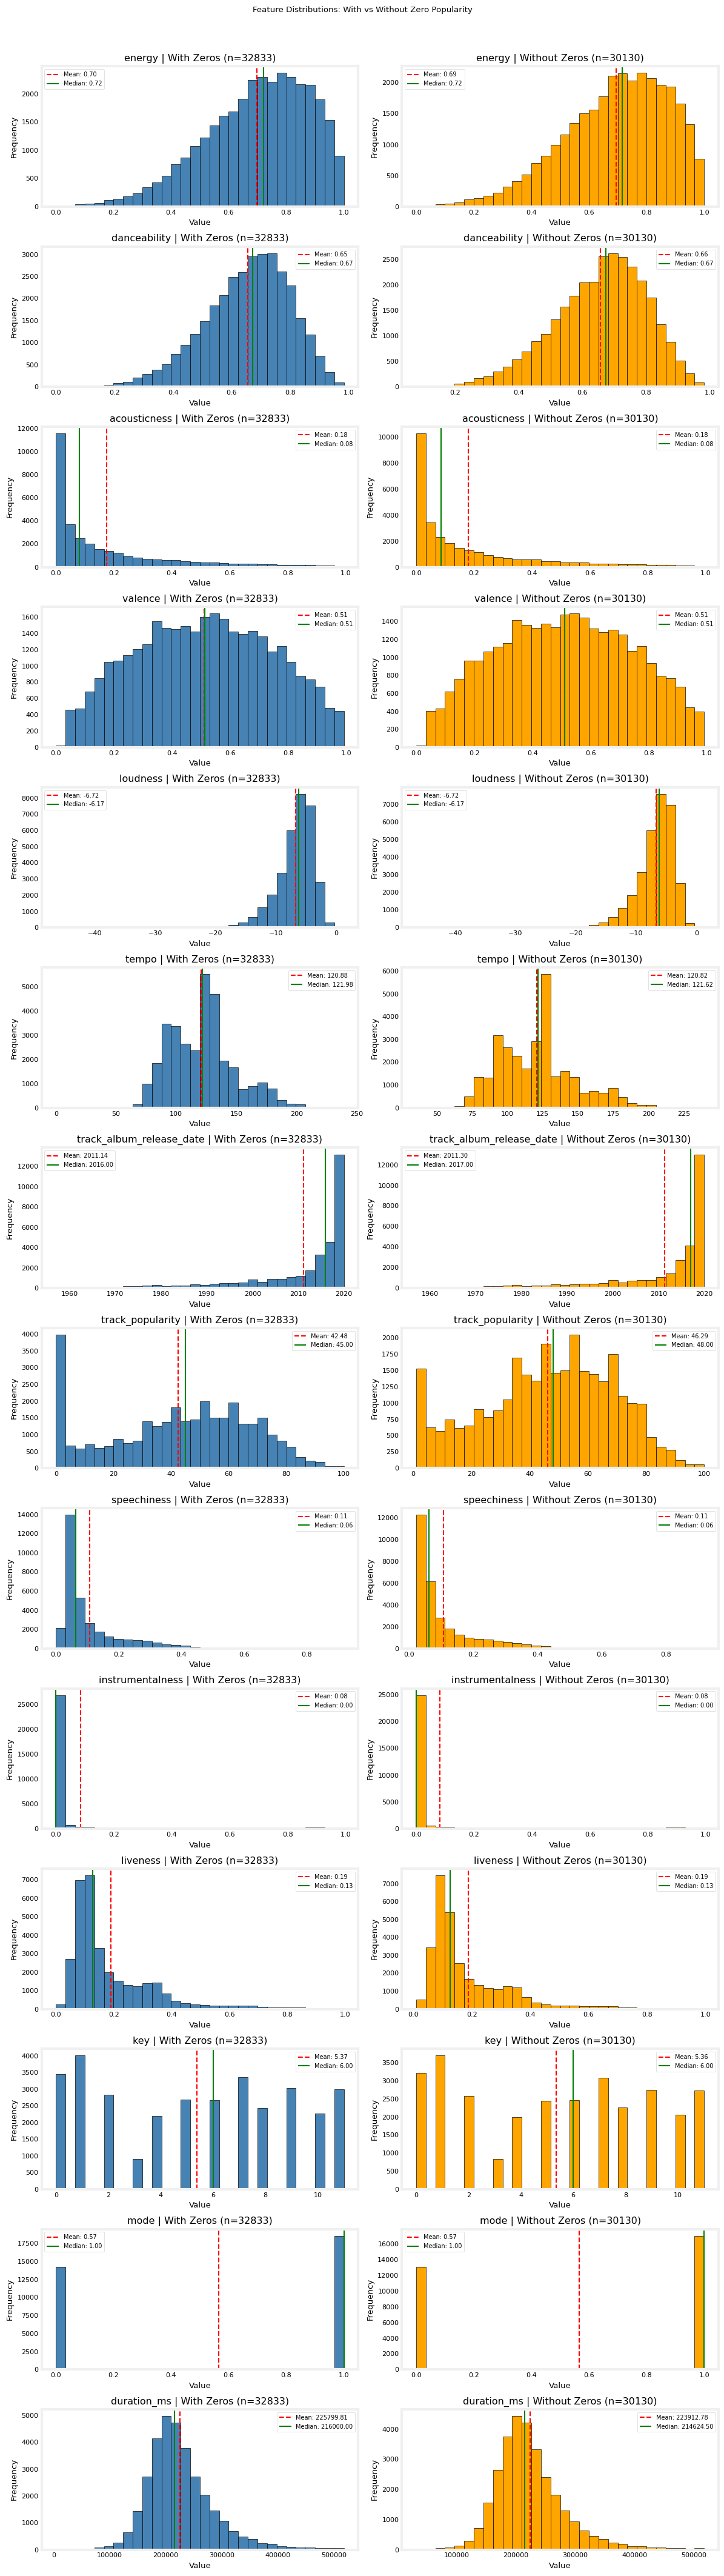

In [48]:
# Compare all feature distributions with and without zero popularity
df_with_zeros = pd.read_csv("spotify_songs.csv")
year_series = pd.to_datetime(
    df_with_zeros["track_album_release_date"], format="mixed"
).dt.year
df_with_zeros["track_album_release_date"] = year_series.fillna(
    year_series.mean()
).astype(int)
df_without_zeros = df_with_zeros[df_with_zeros["track_popularity"] != 0]

features = [
    "energy",
    "danceability",
    "acousticness",
    "valence",
    "loudness",
    "tempo",
    "track_album_release_date",
    "track_popularity",
    "speechiness",
    "instrumentalness",
    "liveness",
    "key",
    "mode",
    "duration_ms",
]

fig, axes = plt.subplots(len(features), 2, figsize=(12, len(features) * 3))
plt.suptitle("Feature Distributions: With vs Without Zero Popularity", y=1.01)

for i, feature in enumerate(features):
    for j, (df, label, color) in enumerate(
        [
            (df_with_zeros, f"With Zeros (n={len(df_with_zeros)})", "steelblue"),
            (df_without_zeros, f"Without Zeros (n={len(df_without_zeros)})", "orange"),
        ]
    ):
        ax = axes[i, j]
        mean = df[feature].mean()
        median = df[feature].median()

        ax.hist(df[feature], bins=30, edgecolor="black", color=color)
        ax.axvline(
            mean, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean:.2f}"
        )
        ax.axvline(
            median,
            color="green",
            linestyle="-",
            linewidth=1.5,
            label=f"Median: {median:.2f}",
        )
        ax.set_title(f"{feature} | {label}")
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")
        ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

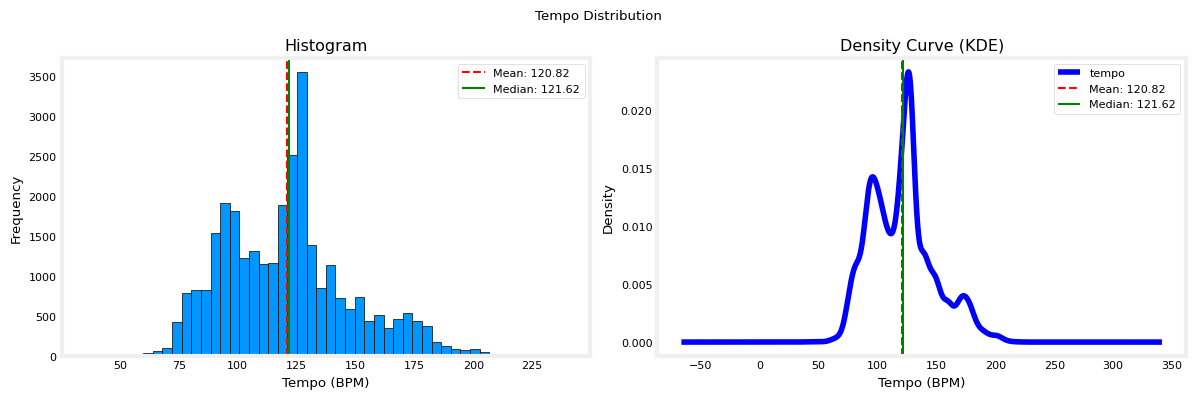

In [45]:
# Detailed tempo distribution plot
mean_tempo = data_frame["tempo"].mean()
median_tempo = data_frame["tempo"].median()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plt.suptitle("Tempo Distribution")

# Histogram
axes[0].hist(data_frame["tempo"], bins=50, edgecolor="black")
axes[0].axvline(
    mean_tempo,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Mean: {mean_tempo:.2f}",
)
axes[0].axvline(
    median_tempo,
    color="green",
    linestyle="-",
    linewidth=1.5,
    label=f"Median: {median_tempo:.2f}",
)
axes[0].set_title("Histogram")
axes[0].set_xlabel("Tempo (BPM)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# KDE (smooth curve) to better see the shape
data_frame["tempo"].plot.kde(ax=axes[1], color="blue")
axes[1].axvline(
    mean_tempo,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Mean: {mean_tempo:.2f}",
)
axes[1].axvline(
    median_tempo,
    color="green",
    linestyle="-",
    linewidth=1.5,
    label=f"Median: {median_tempo:.2f}",
)
axes[1].set_title("Density Curve (KDE)")
axes[1].set_xlabel("Tempo (BPM)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.savefig("tempo_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_1743/4229238455.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_1743/4229238455.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_1743/4229238455.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_1743/4229238455.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_1743/4229238455.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been ren

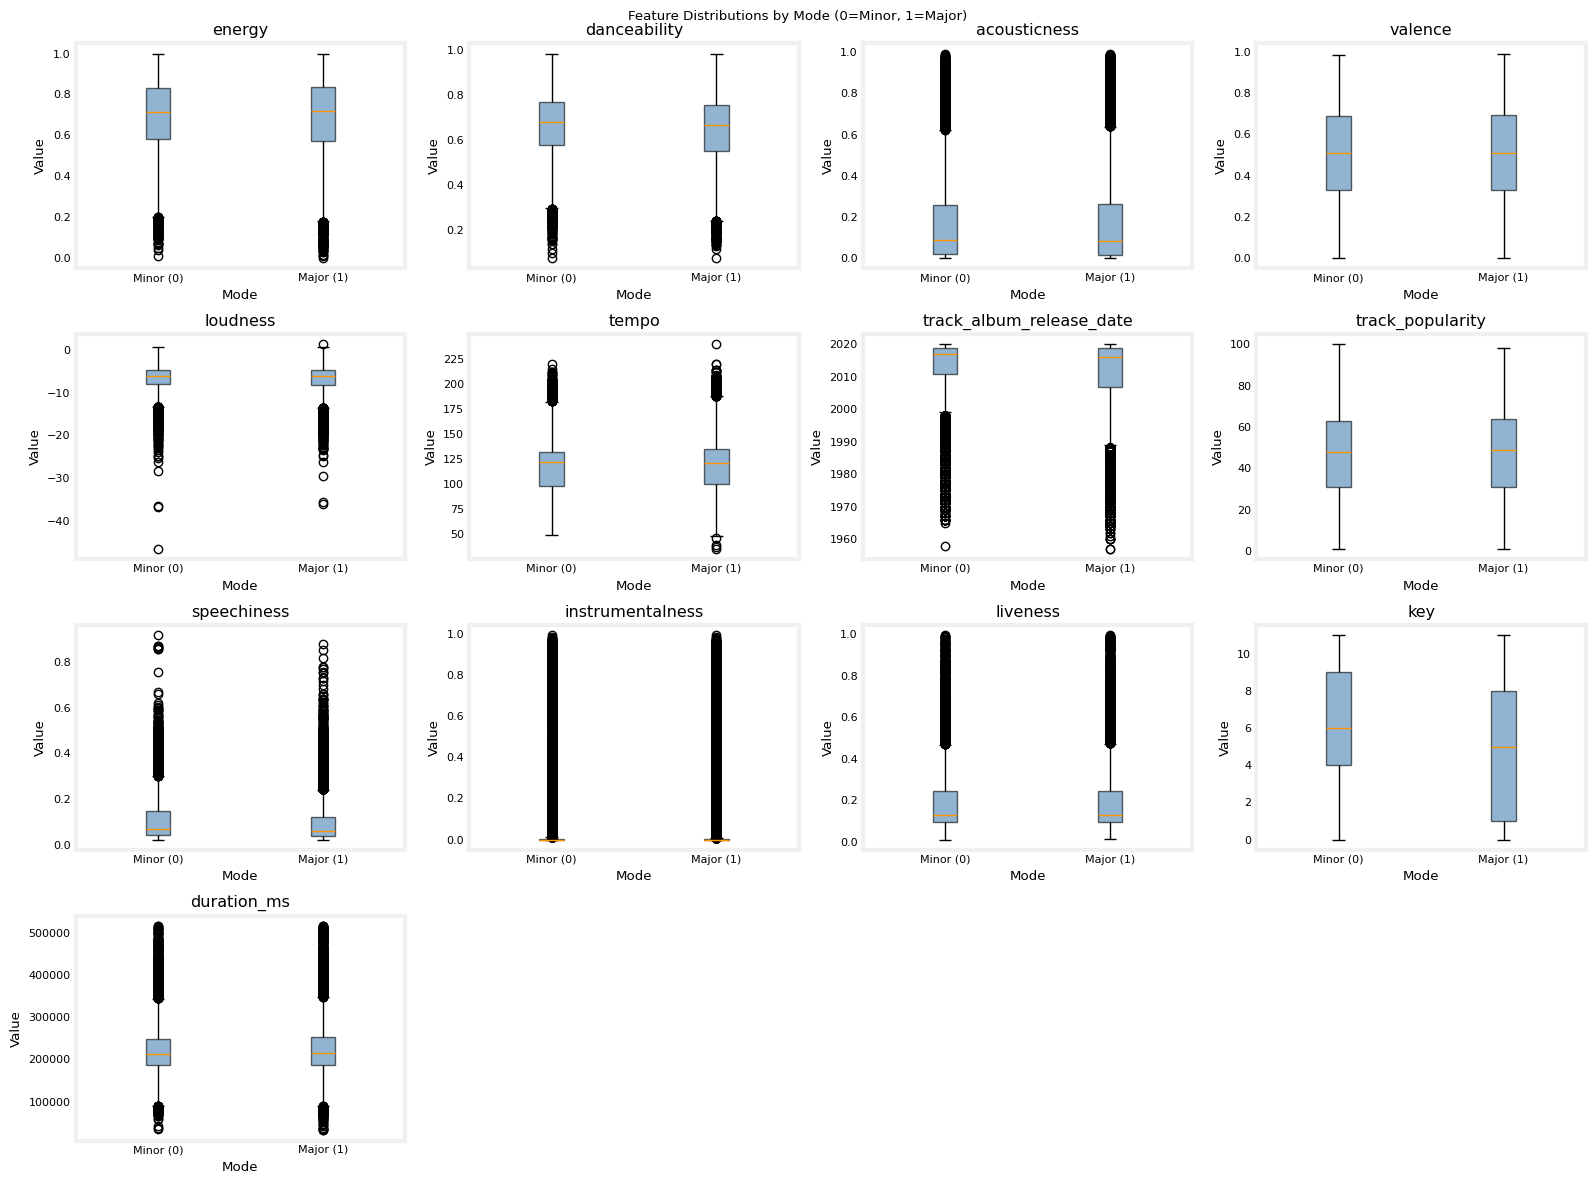

In [9]:
# Graph mode (binary: 0=minor, 1=major) against all features using box plots
features_vs_mode = [
    "energy",
    "danceability",
    "acousticness",
    "valence",
    "loudness",
    "tempo",
    "track_album_release_date",
    "track_popularity",
    "speechiness",
    "instrumentalness",
    "liveness",
    "key",
    "duration_ms",
]

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
plt.suptitle("Feature Distributions by Mode (0=Minor, 1=Major)")

for ax, feature in zip(axes.flatten(), features_vs_mode):
    minor = data_frame[data_frame["mode"] == 0][feature]
    major = data_frame[data_frame["mode"] == 1][feature]

    ax.boxplot(
        [minor, major],
        labels=["Minor (0)", "Major (1)"],
        patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.6),
    )
    ax.set_title(feature)
    ax.set_xlabel("Mode")
    ax.set_ylabel("Value")

for ax in axes.flatten()[len(features_vs_mode) :]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig("mode_vs_features.png", dpi=150, bbox_inches="tight")
plt.show()

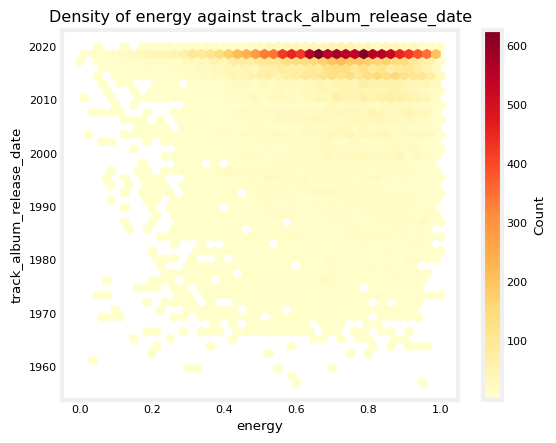

In [46]:
# Scatter plot 2 columns to see the relationship

# x_features = ["energy", "danceability", "acousticness", "valence", "loudness", "tempo", "track_album_release_date"]

# featurex = "energy"
# plt.scatter(data_frame[featurex], data_frame[target])
# plt.title(f"Scatter of {data_frame[featurex].name} against {data_frame[target].name}")
# plt.ylabel(f"{data_frame[target].name} Data")
# plt.xlabel(f"{data_frame[featurex].name} Data")
# plt.show()

# Scatter plot multiple features against target in one image
feature = "energy"

plt.hexbin(
    data_frame[feature], data_frame[target], gridsize=40, cmap="YlOrRd", mincnt=1
)
plt.title(f"Density of {feature} against {target}")
plt.xlabel(feature)
plt.ylabel(target)
plt.colorbar(label="Count")
plt.show()

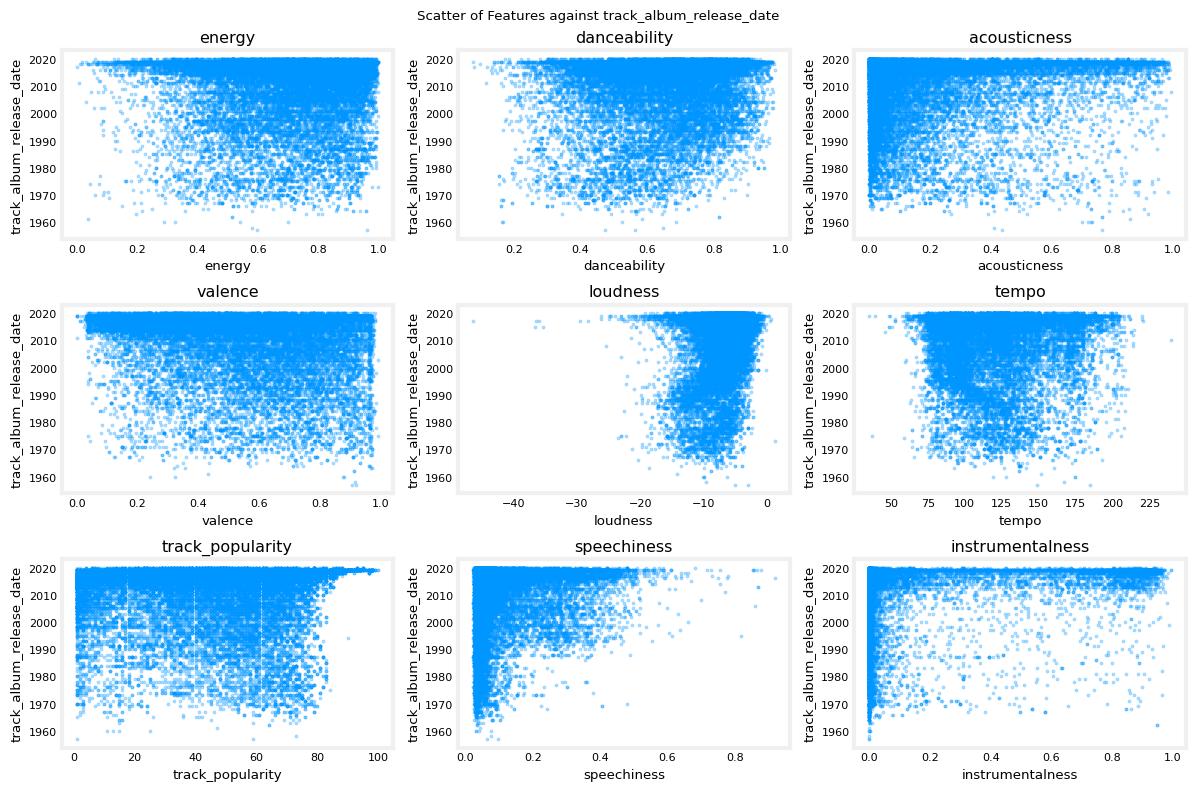

In [49]:
# Scatter plot multiples columns to see the relationship
# x_plot = ['BMI', 'BP']
# for col in x_plot:
#     plt.scatter(data_frame[col], data_frame[target], marker='x')
# plt.title(f"Scatter of {*x_plot,} against {data_frame[target].name}")
# plt.ylabel(f"{data_frame[target].name} Data")
# plt.xlabel(f"{*x_plot,} Data")
# plt.show()

# Scatter plot multiple features against target in one image
x_features = [
    "energy",
    "danceability",
    "acousticness",
    "valence",
    "loudness",
    "tempo",
    "track_popularity",
    "speechiness",
    "instrumentalness",
    "liveness",
    "key",
    "mode",
    "duration_ms",
]

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
plt.suptitle(f"Scatter of Features against {target}")

for ax, feature in zip(axes.flatten(), x_features):
    ax.scatter(data_frame[feature], data_frame[target], alpha=0.3, s=5)
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel(target)

# Hide any unused subplots
for ax in axes.flatten()[len(x_features) :]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
x_features = [
    "energy",
    "danceability",
    "acousticness",
    "valence",
    "loudness",
    "tempo",
    "track_album_release_date",
]

fig, axes = plt.subplots(3, 3, figsize=(12, 8))
plt.suptitle(f"Density of Features against {target}")

for ax, feature in zip(axes.flatten(), x_features):
    ax.hexbin(
        data_frame[feature], data_frame[target], gridsize=40, cmap="YlOrRd", mincnt=1
    )
    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel(target)

# Hide any unused subplots
for ax in axes.flatten()[len(x_features) :]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Scatter plot 2 columns in separate charts with a shared y-axis
fig, (ax1, ax2) = plt.subplots(1,2, sharey=True)
plt.suptitle(f"Scatter of {data_frame['BMI'].name} and {data_frame['BP'].name} against {data_frame[target].name}")
ax1.set_ylabel(f"{data_frame[target].name} Data")

ax1.scatter(data_frame['BMI'], data_frame[target])
ax1.set_xlabel(f"{data_frame['BMI'].name} Data")

ax2.scatter(data_frame['BP'], data_frame[target])
ax2.set_xlabel(f"{data_frame['BP'].name} Data")

plt.show()

In [ ]:
# 3D Scatter plot 3 columns to see the relationship

x_plot = ['BMI', 'BP']

fig = plt.figure()
plt.suptitle(f"3D Scatter of {*x_plot,} against {data_frame[target].name}")
ax = fig.add_subplot(111, projection='3d')

ax.scatter(data_frame[x_plot[0]], data_frame[x_plot[1]], data_frame[target], color='blue')

x1_range = np.linspace(data_frame[x_plot[0]].min(), data_frame[x_plot[0]].max())
x2_range = np.linspace(data_frame[x_plot[1]].min(), data_frame[x_plot[1]].max())
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)


ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel(target)

plt.show()